In [7]:
# IMPORTING LIBRARIES 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")


In [8]:
# LOADING THE DATA :-

df = pd.read_csv("movies.csv")
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [9]:
#get information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31021 entries, 0 to 31020
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Name      31021 non-null  object
 1   Year      29963 non-null  object
 2   Duration  14481 non-null  object
 3   Genre     27265 non-null  object
 4   Rating    15839 non-null  object
 5   Votes     15841 non-null  object
 6   Director  29969 non-null  object
 7   Actor 1   27785 non-null  object
 8   Actor 2   26251 non-null  object
 9   Actor 3   24731 non-null  object
dtypes: object(10)
memory usage: 2.4+ MB


In [10]:
# get summary statistics of the datset
df.describe()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
count,31021,29963,14481,27265,15839,15841,29969,27785,26251,24731
unique,13841,103,183,486,85,2035,5939,4719,4892,4821
top,Mamta,(2019),120 min,Drama,6.2,8,Jayant Desai,Ashok Kumar,Rekha,Pran
freq,14,820,480,5560,538,454,116,316,166,182


In [11]:
df.dtypes

Name        object
Year        object
Duration    object
Genre       object
Rating      object
Votes       object
Director    object
Actor 1     object
Actor 2     object
Actor 3     object
dtype: object

In [12]:
df.shape

(31021, 10)

In [13]:
df.isna().sum()

Name            0
Year         1058
Duration    16540
Genre        3756
Rating      15182
Votes       15180
Director     1052
Actor 1      3236
Actor 2      4770
Actor 3      6290
dtype: int64

In [14]:
df.isna().sum()

Name            0
Year         1058
Duration    16540
Genre        3756
Rating      15182
Votes       15180
Director     1052
Actor 1      3236
Actor 2      4770
Actor 3      6290
dtype: int64

In [15]:
df.dropna(subset=['Rating'], inplace=True)

In [16]:
df.isna().sum()

Name           0
Year           0
Duration    4136
Genre        204
Rating         0
Votes          0
Director      10
Actor 1      250
Actor 2      400
Actor 3      584
dtype: int64

In [17]:

df['Genre'].fillna('Unknown', inplace=True)

In [18]:
df.isna().sum()

Name           0
Year           0
Duration    4136
Genre          0
Rating         0
Votes          0
Director      10
Actor 1      250
Actor 2      400
Actor 3      584
dtype: int64

In [19]:
# Extract numeric values from 'Duration' and convert to integers
df['Duration'] = df['Duration'].str.extract(r'(\d+)').astype(float)

# Impute missing values in 'Duration' with the median
df['Duration'].fillna(df['Duration'].median(), inplace=True)

In [20]:
df.dropna(subset=['Actor 1', 'Actor 2', 'Actor 3'], inplace=True)

In [21]:
df.isna().sum()

Name        0
Year        0
Duration    0
Genre       0
Rating      0
Votes       0
Director    0
Actor 1     0
Actor 2     0
Actor 3     0
dtype: int64

In [22]:
# check datatypes
df.dtypes

Name         object
Year         object
Duration    float64
Genre        object
Rating       object
Votes        object
Director     object
Actor 1      object
Actor 2      object
Actor 3      object
dtype: object

In [23]:
# Change the data type of both Year and Votes column to numerical data types

df['Year'] = pd.to_numeric(df['Year'].astype(str).str.extract(r'(\d+)')[0], errors='coerce')

df['Votes'] = pd.to_numeric(df['Votes'].astype(str).str.extract(r'(\d+)')[0], errors='coerce')

In [24]:
df.dtypes

Name         object
Year        float64
Duration    float64
Genre        object
Rating       object
Votes       float64
Director     object
Actor 1      object
Actor 2      object
Actor 3      object
dtype: object

In [25]:
# preview the clean dataset
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
1,#Gadhvi (He thought he was Gandhi),2019.0,109.0,Drama,7.0,8.0,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
3,#Yaaram,2019.0,110.0,"Comedy, Romance",4.4,35.0,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
5,...Aur Pyaar Ho Gaya,1997.0,147.0,"Comedy, Drama, Musical",4.7,827.0,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor
6,...Yahaan,2005.0,142.0,"Drama, Romance, War",7.4,1.0,Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma
8,?: A Question Mark,2012.0,82.0,"Horror, Mystery, Thriller",5.6,326.0,Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia


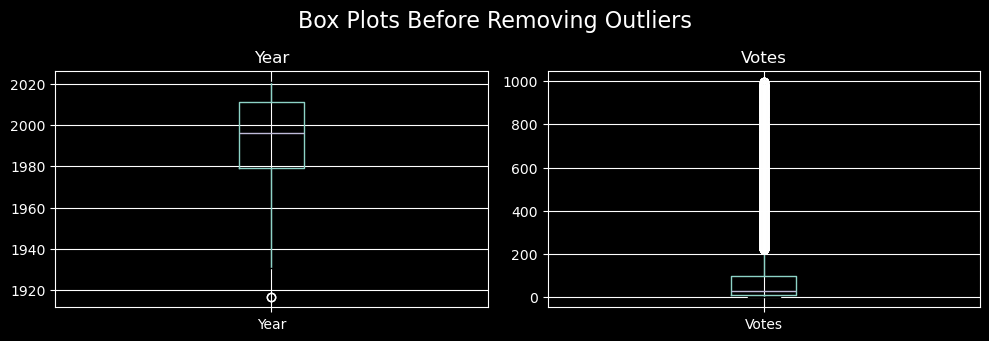

Number of rows with outliers before removal: 1562


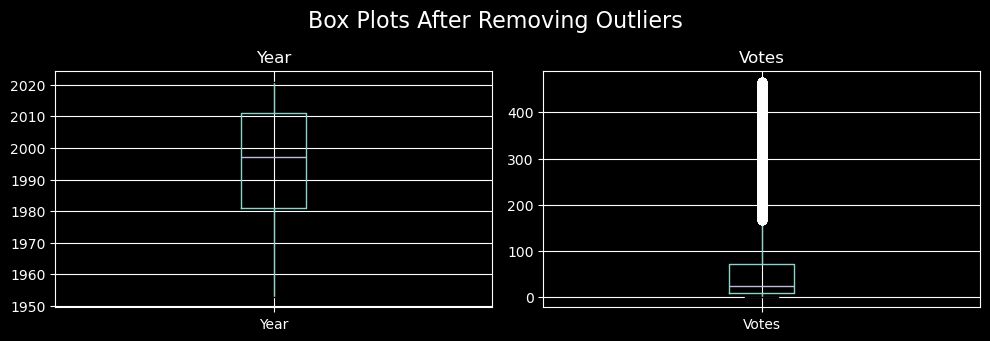

Number of rows after removing outliers: 13693


In [26]:
# Checking for outliers and remove them

# Set the dark_background style
plt.style.use('dark_background')

# Define the numerical columns you want to check for outliers
numerical_columns = ['Year', 'Votes']

# Create box plots before removing outliers
plt.figure(figsize=(10, 6))
plt.suptitle('Box Plots Before Removing Outliers', fontsize=16)

for i, column in enumerate(numerical_columns, 1):
    plt.subplot(2, 2, i)
    df.boxplot(column=[column])
    plt.title(f'{column}')

plt.tight_layout()
plt.show()

# Calculate z-scores for numerical columns
z_scores = pd.DataFrame()
for column in numerical_columns:
    z_scores[column] = (df[column] - df[column].mean()) / df[column].std()

# Set a z-score threshold to identify outliers (e.g., 2 or -2 for a 95% confidence interval)
z_score_threshold = 2

# Identify outliers based on z-scores
outliers = z_scores[(z_scores.abs() > z_score_threshold).any(axis=1)]

# Display the number of rows with outliers before removal
print("Number of rows with outliers before removal:", len(outliers))

# Remove outliers and create a new DataFrame (df_cleaned)
df = df[~((z_scores.abs() > z_score_threshold).any(axis=1))]

# Create box plots after removing outliers
plt.figure(figsize=(10, 6))
plt.suptitle('Box Plots After Removing Outliers', fontsize=16)

for i, column in enumerate(numerical_columns, 1):
    plt.subplot(2, 2, i)
    df.boxplot(column=[column])
    plt.title(f'{column}')

plt.tight_layout()
plt.show()

# Display the number of rows after removing outliers
print("Number of rows after removing outliers:", len(df))

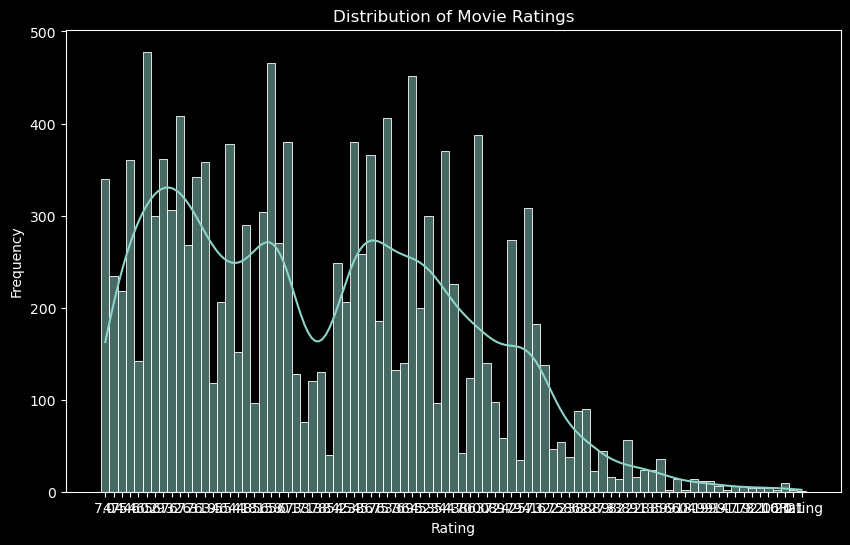

In [27]:
# rating analysis
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Rating', bins=30, kde=True)
plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()


Rating Distribution: The histogram shows a slightly normal distribution with a peak around a 7 rating value.
Common Rating Range falls between 5 to 7.
All ratings are positive
There are few movies rated below 2 and above 8

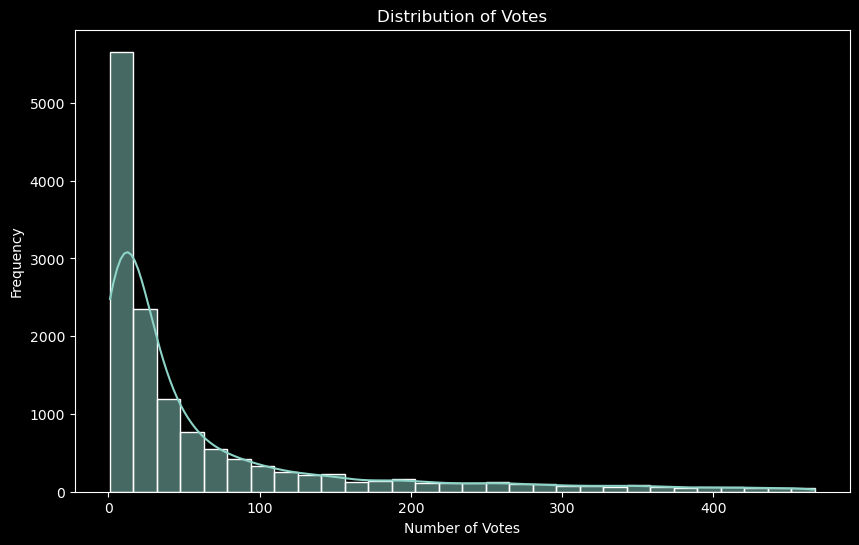

In [28]:
# Votes Analysis

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Votes', bins=30, kde=True)
plt.title('Distribution of Votes')
plt.xlabel('Number of Votes')
plt.ylabel('Frequency')
plt.show()

The distribution of votes is right-skewed, with the majority of movies receiving a relatively low number of votes. This suggests that many movies in the dataset may not be widely recognized or popular, as they have received fewer votes
The long tail towards higher vote counts indicates that there are a smaller number of movies that have garnered a significant number of votes
Popularity Range is between 0 and 50

Top 10 Directors with the Most Movies Directed

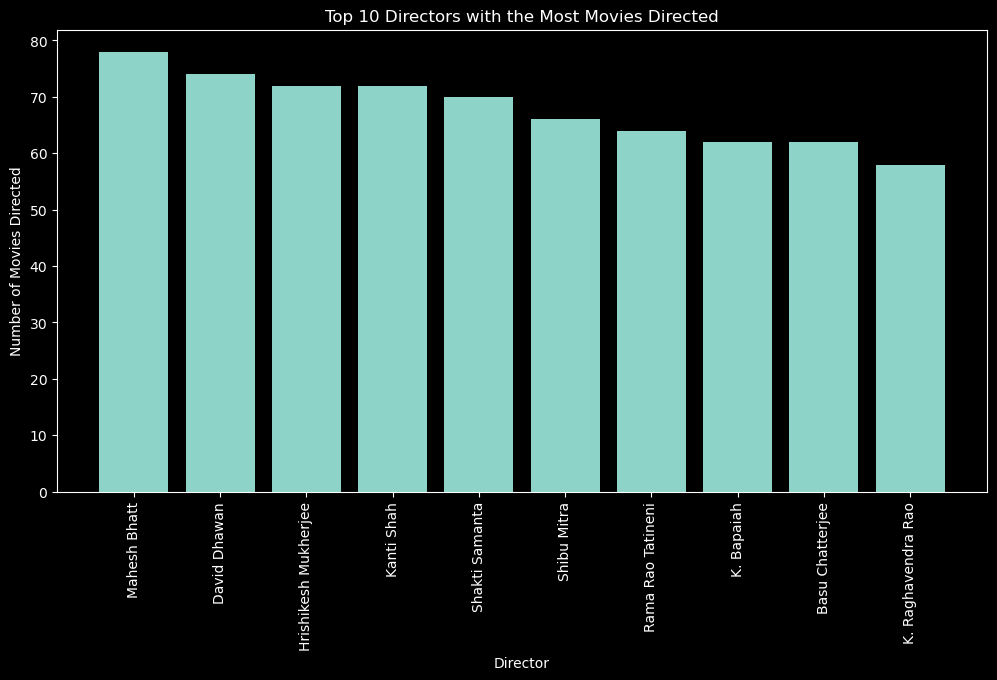

In [29]:
# Count the number of movies directed by each director
director_counts = df['Director'].value_counts()

# Select the top 10 directors with the most movies directed
top_10_directors = director_counts.head(10)

# Create a bar plot to visualize the top 10 directors with the most movies directed
plt.figure(figsize=(12, 6))
plt.bar(top_10_directors.index, top_10_directors.values),
plt.title('Top 10 Directors with the Most Movies Directed')
plt.xlabel('Director')
plt.ylabel('Number of Movies Directed')
plt.xticks(rotation=90)
plt.show()


The above directors are quite prolific in their careers.
Mahesh Bhatt directed the most movies

Top 10 Actors with the Most Movie Appearances

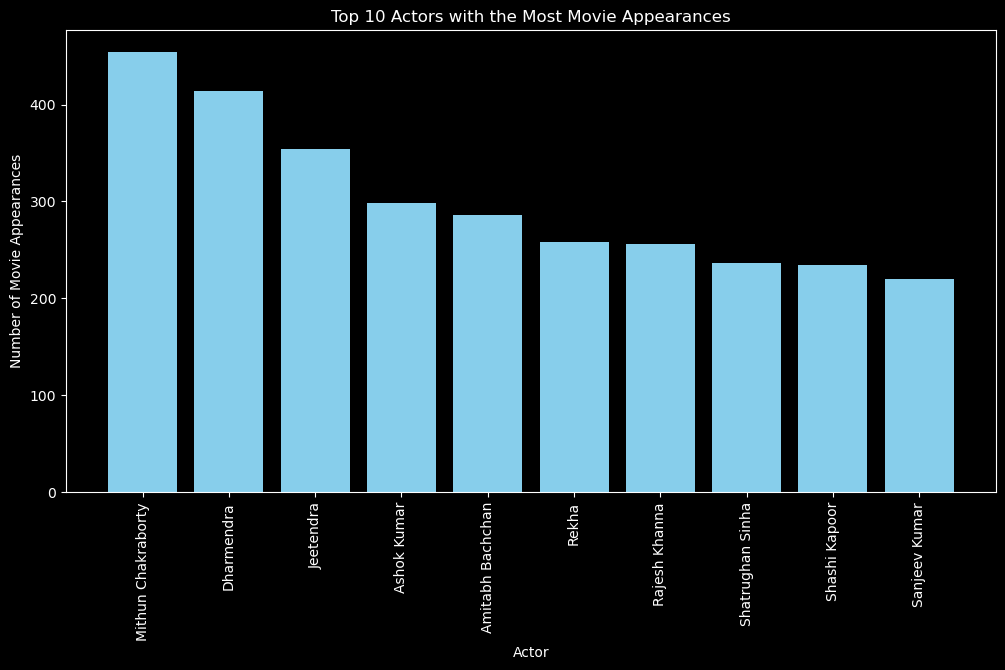

In [30]:
# Count the number of movies in which each actor starred
actor_counts = df[['Actor 1', 'Actor 2', 'Actor 3']].stack().value_counts()

# Select the top 10 actors with the most movie appearances
top_10_actors = actor_counts.head(10)

# Create a bar plot to visualize the top 10 actors with the most movie appearances
plt.figure(figsize=(12, 6))
plt.bar(top_10_actors.index, top_10_actors.values,  color='skyblue')
plt.title('Top 10 Actors with the Most Movie Appearances')
plt.xlabel('Actor')
plt.ylabel('Number of Movie Appearances')
plt.xticks(rotation=90)
plt.show()

The actor who appeared the most in these movies is Mithun Chakraborty

Bivariate Analysis:
==================================
Bivariate analysis helps you understand the relationships between two variables

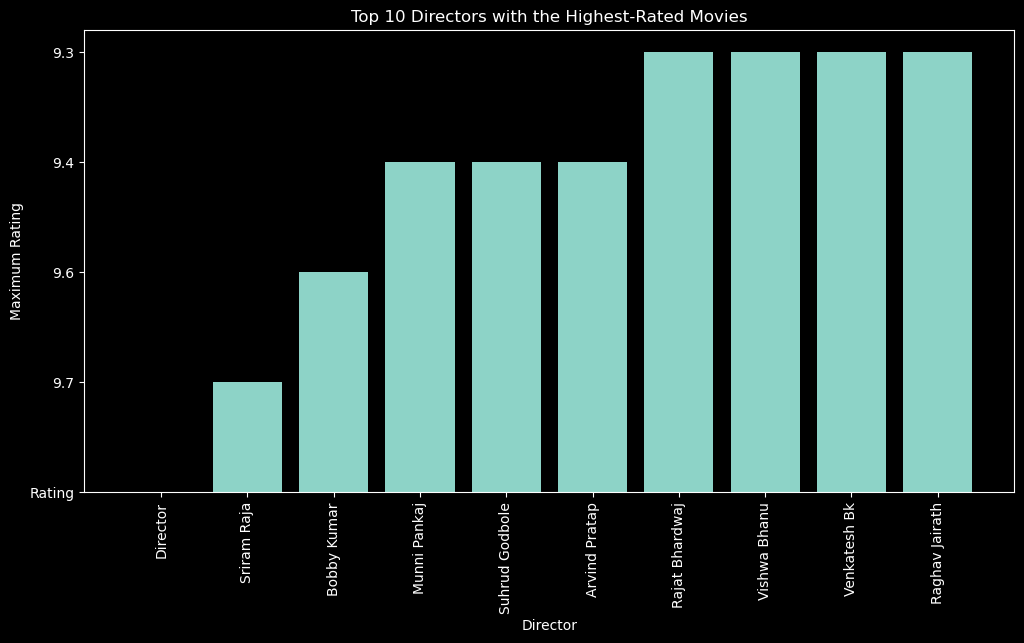

In [31]:

# Top 10 Directors with the Highest-Rated Movies

# Group the data by director and find the maximum rating within each group
directors_max_rating = df.groupby('Director')['Rating'].max()

# Sort the directors by their highest rating in descending order and select the top 10
top_10_directors = directors_max_rating.sort_values(ascending=False).head(10)

# Create a bar plot to visualize the top 10 directors with the highest-rated movies
plt.figure(figsize=(12, 6))
plt.bar(top_10_directors.index, top_10_directors.values)
plt.title('Top 10 Directors with the Highest-Rated Movies')
plt.xlabel('Director')
plt.ylabel('Maximum Rating')
plt.xticks(rotation=90)
plt.show()


In [32]:
df['Rating'].dtype


dtype('O')

In [33]:
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')

In [34]:
df = df.dropna(subset=['Rating'])

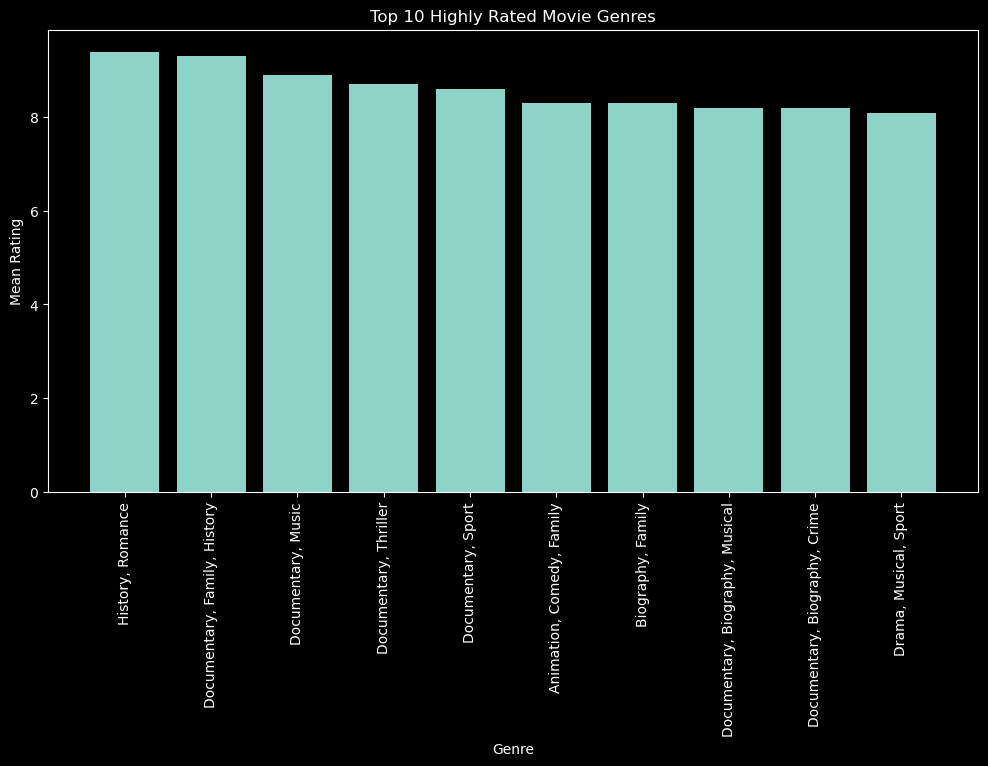

In [35]:
# Group the data by genre and calculate the mean rating for each genre
genre_mean_ratings = df.groupby('Genre')['Rating'].mean()

top_10_genres = genre_mean_ratings.sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
plt.bar(top_10_genres.index, top_10_genres.values)
plt.title("Top 10 Highly Rated Movie Genres")
plt.xlabel("Genre")
plt.ylabel("Mean Rating")
plt.xticks(rotation=90)
plt.show()

Genre Popularity:
=================
The top 10 highly rated genres are likely to be popular among audiences, as reflected in their mean ratings
History, Romance genre has the highes rating hence wise to investing in the genre

Critical Acclaim:
================
High mean ratings often indicate that these genres receive positive reviews and critical acclaim from both audiences and critics.
Filmmakers, actors, and production companies may consider collaborating within these genres to create well received movies.

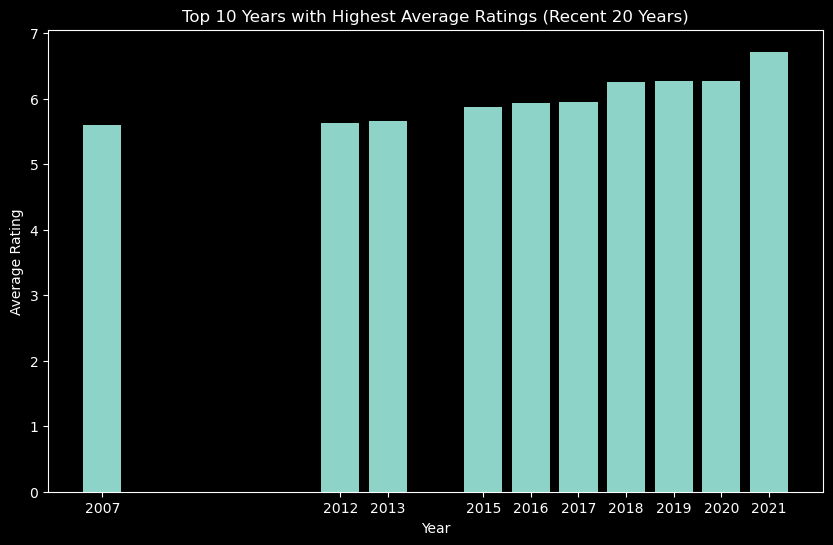

In [36]:
# Top 10 Years with Highest Average Ratings

# Filter the DataFrame for the most recent 20 years
recent_years = df[df['Year'] >= (max(df['Year']) - 19)]

# Calculate the average rating per year
average_ratings = recent_years.groupby('Year')['Rating'].mean().reset_index()

# Sort the DataFrame by average rating in descending order and select the top 10 years
top_10_years = average_ratings.nlargest(10, 'Rating')

# Plot the top 10 years and their average ratings
plt.figure(figsize=(10, 6))
plt.bar(top_10_years['Year'], top_10_years['Rating'])
plt.xlabel('Year')
plt.ylabel('Average Rating')
plt.title('Top 10 Years with Highest Average Ratings (Recent 20 Years)')
plt.xticks(top_10_years['Year'])
plt.show()

Consistency: Over the recent 20 years, there seems to be a range of years with high average ratings, indicating some consistency in the quality of movies during those years

Duration vs Rating

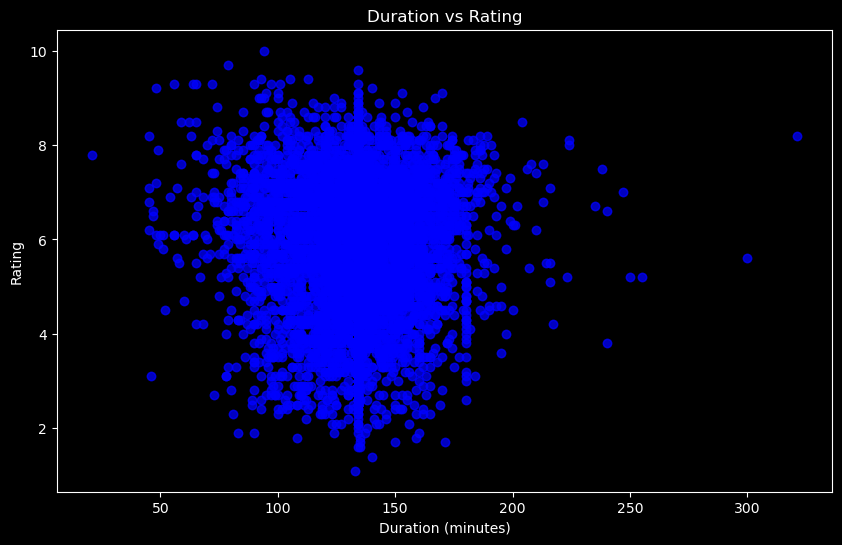

In [37]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Duration'], df['Rating'], alpha=0.5, color='blue')
plt.xlabel('Duration (minutes)')
plt.ylabel('Rating')
plt.title('Duration vs Rating')
plt.show()

There doesn't appear to be a strong linear relationship between movie duration and ratings.you can't easily predict a movie's rating based solely on its duration.

Multivariate Analysis:
======================================
Multivariate analysis involves exploring the relationships between more than two variables.

Correlation Matrix

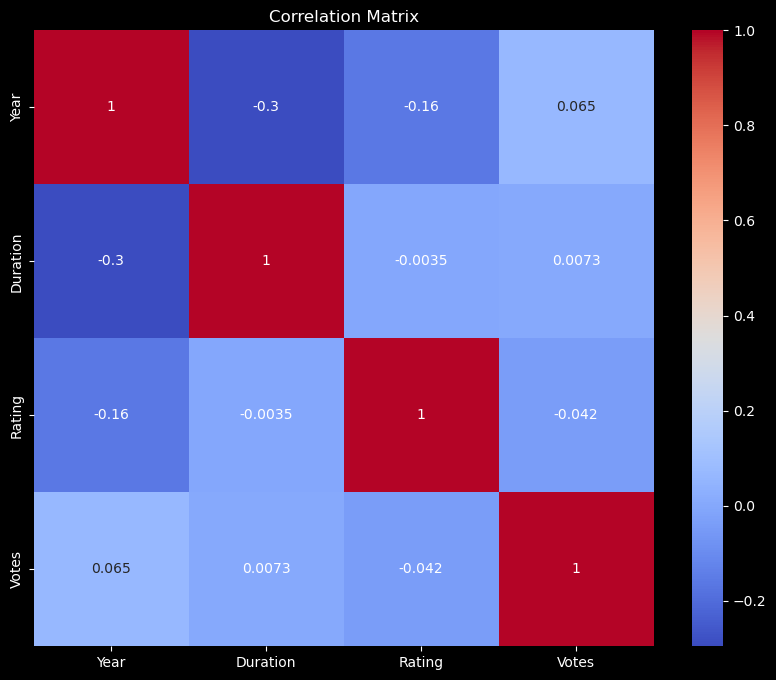

In [38]:
# Calculate the correlation matrix
numeric_df = df.select_dtypes(include=['int64','float64'])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

The variables are not Highly correlated. The absence of strong correlations between numerical variables is a positive sign, as it reduces the risk of multicollinearity in regression analysis

Pairplot

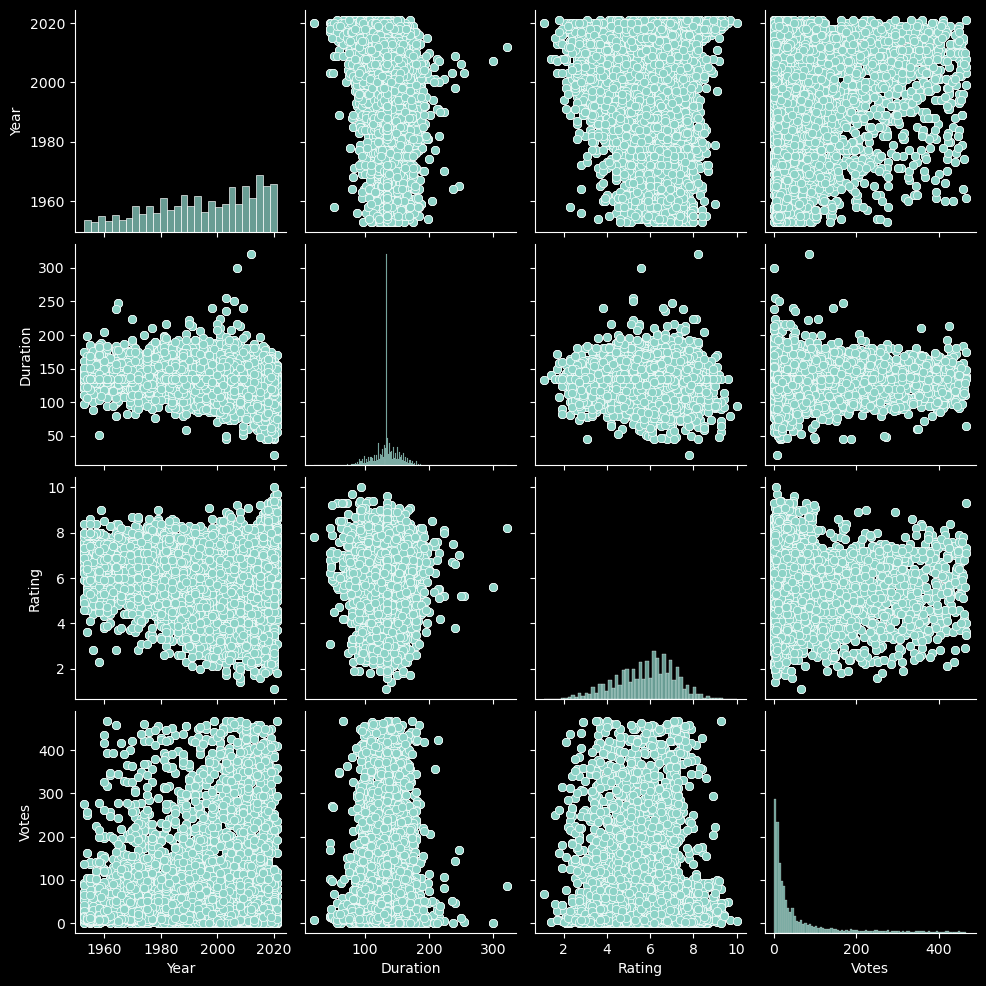

In [39]:
# Select the numerical variables for the pair plot
numerical_columns = df.select_dtypes(include=['number'])

# Create a pair plot for the numerical variables
sns.pairplot(numerical_columns)
plt.show()

No strong correlation between variables

Data Preprocessing
=======================
Assign the variables
=====================
assigning y/ target variable to Rating column for prediction analysis and the rest of the features to independent variable X

In [40]:
X = df.drop('Rating', axis=1)
y = df['Rating']

In [41]:

X.head()

,Name,Year,Duration,Genre,Votes,Director,Actor 1,Actor 2,Actor 3
1,#Gadhvi (He thought he was Gandhi),2019.0,109.0,Drama,8.0,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
3,#Yaaram,2019.0,110.0,"Comedy, Romance",35.0,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
6,...Yahaan,2005.0,142.0,"Drama, Romance, War",1.0,Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma
8,?: A Question Mark,2012.0,82.0,"Horror, Mystery, Thriller",326.0,Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia
9,@Andheri,2014.0,116.0,"Action, Crime, Thriller",11.0,Biju Bhaskar Nair,Augustine,Fathima Babu,Byon


Check for mutlicollinearity X

In [42]:
X.corr(numeric_only=True)

,Year,Duration,Votes
Year,1.000000,-0.295635,0.064510
Duration,-0.295635,1.000000,0.007258
Votes,0.064510,0.007258,1.000000


One-hot encode the categorical variables
==================================
One-hot encoding is used to convert categorical variables into a binary format, which is suitable for machine learning algorithms

In [43]:
df.columns

Index(['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director',
       'Actor 1', 'Actor 2', 'Actor 3'],
      dtype='object')

In [44]:
from sklearn.preprocessing import OneHotEncoder
# Specify the categorical columns to be one-hot encoded
categorical_columns = ['Genre']


# Initialize the OneHotEncoder
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Fit and transform the categorical columns
X_categorical_encoded = ohe.fit_transform(X[categorical_columns])

# Retrieve feature names for the encoded columns
feature_names = ohe.get_feature_names_out(categorical_columns)


# Create a DataFrame for the encoded features
X_categorical_encoded_df = pd.DataFrame(
    X_categorical_encoded,
    columns=feature_names
)

X_categorical_encoded_df.head()

,Genre_Action,"Genre_Action, Adventure","Genre_Action, Adventure, Biography","Genre_Action, Adventure, Comedy","Genre_Action, Adventure, Crime","Genre_Action, Adventure, Drama","Genre_Action, Adventure, Family","Genre_Action, Adventure, Fantasy","Genre_Action, Adventure, History","Genre_Action, Adventure, Horror",...,Genre_Sci-Fi,"Genre_Sci-Fi, Thriller",Genre_Sport,Genre_Thriller,"Genre_Thriller, Action","Genre_Thriller, Musical, Mystery","Genre_Thriller, Mystery","Genre_Thriller, Mystery, Family",Genre_Unknown,Genre_War
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Scaling Numerical Features

In [46]:
from sklearn.preprocessing import MinMaxScaler
# Specify the numerical columns to be scaled
numerical_columns = ['Year', 'Duration', 'Votes']

# Initialize the StandardScaler
scaler = MinMaxScaler()

# Fit and transform the selected numerical columns
X_numeric_scaled = scaler.fit_transform(X[numerical_columns])

# Create a DataFrame for the scaled features
X_numeric_scaled_df = pd.DataFrame(X_numeric_scaled, columns=numerical_columns)
X_numeric_scaled_df.head()

# combine the scaled columns and onehotencoded columns
X_final = pd.concat([X_numeric_scaled_df, X_categorical_encoded_df], axis=1)

X_final.head()

,Year,Duration,Votes,Genre_Action,"Genre_Action, Adventure","Genre_Action, Adventure, Biography","Genre_Action, Adventure, Comedy","Genre_Action, Adventure, Crime","Genre_Action, Adventure, Drama","Genre_Action, Adventure, Family",...,Genre_Sci-Fi,"Genre_Sci-Fi, Thriller",Genre_Sport,Genre_Thriller,"Genre_Thriller, Action","Genre_Thriller, Musical, Mystery","Genre_Thriller, Mystery","Genre_Thriller, Mystery, Family",Genre_Unknown,Genre_War
0,0.970588,0.293333,0.015021,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.970588,0.296667,0.072961,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.764706,0.403333,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.867647,0.203333,0.697425,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.897059,0.316667,0.021459,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Scaling y

In [47]:
# Instantiate StandardScaler
scaler = MinMaxScaler()

# Reshape 'Rating' to a 2D array for StandardScaler
y_scaled = scaler.fit_transform(df['Rating'].values.reshape(-1, 1))

# Convert 'y_scaled' back to a DataFrame
y = pd.DataFrame(y_scaled, columns=['Rating'])
y

,Rating
0,0.662921
1,0.370787
2,0.707865
3,0.505618
4,0.325843
...,...
13687,0.426966
13688,0.471910
13689,0.528090
13690,0.393258


Train-Test Split

In [48]:
# Split the data into training and testing data 

X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.3, random_state=42)

Modeling
===============================
Baseline Model - Linear Regression
=================================
Linear regression is a simple and interpretable model that assumes a linear relationship between the independent variables and the target variable. It can be a good baseline model to start with.

In [49]:
from sklearn.linear_model import LinearRegression
# Create a Linear Regression model
lr_model = LinearRegression()

# Fit the model on the training data
lr_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred_test = lr_model.predict(X_test)
y_pred_train = lr_model.predict(X_train)

Baseline Model Evaluation

In [50]:
# Evaluate the model
mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)
mse_train = mean_squared_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)

print(f"Test Mean Squared Error : {mse_test}")
print(f"Test R-squared (R^2) Score: {r2_test}")

print(f"Train Mean Squared Error : {mse_train}")
print(f"Train R-squared (R^2) Score: {r2_train}")

Test Mean Squared Error : 0.020024717667390914
Test R-squared (R^2) Score: 0.16155452885916077
Train Mean Squared Error : 0.018412717325382938
Train R-squared (R^2) Score: 0.20563775796718997


The model demonstrates severe overfitting and poor predictive performance on the test data.It has an extremely low training MSE and R-squared of 1.0.The negative test R-squared and relatively high test MSE also suggest poor performance on unseen data.

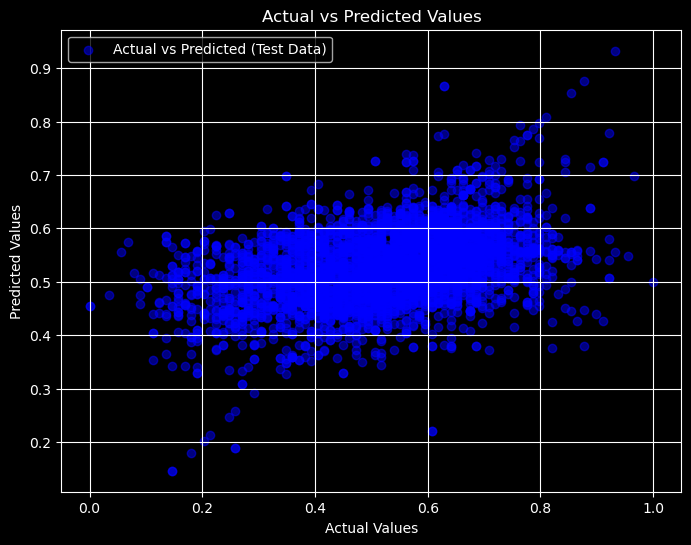

In [51]:
# Create a scatter plot for the test data
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test, alpha=0.5, color='blue', label='Actual vs Predicted (Test Data)')
plt.title('Actual vs Predicted Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

he scatter plot likely shows a scattered pattern of points away from the diagonal line, which aligns with the negative Test R^2 and non-ideal Test MSE. These results collectively suggest that the Linear Regression model is not a good fit for predicting movie ratings and may require improvement, such as exploring more complex models or refining feature selection and engineering.

Second Model: Random Forest Model
================================
A Random Forest is an ensemble machine learning technique that combines multiple decision trees to make more accurate predictions or classifications.Random Forest's ability to handle complexity, noise, and non-linearity, along with its feature importance analysis, makes it a suitable choice for the movie rating prediction.

In [53]:
from sklearn.ensemble import RandomForestRegressor
# Create a Random Forest Regressor model
rf_model = RandomForestRegressor(random_state=42)

# Fit the model on the training data
rf_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred_test = rf_model.predict(X_test)
y_pred_train = rf_model.predict(X_train)

Random Forest model Evaluation

In [54]:
# Evaluate the model
mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)
mse_train = mean_squared_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)

print("Random Forest Regressor Model Evaluation:")
print(f"Test Mean Squared Error: {mse_test}")
print(f"Test R-squared (R^2) Score: {r2_test}")
print(f"Train Mean Squared Error: {mse_train}")
print(f"Train R-squared (R^2) Score: {r2_train}")

Random Forest Regressor Model Evaluation:
Test Mean Squared Error: 0.008271584337809513
Test R-squared (R^2) Score: 0.6536644090373583
Train Mean Squared Error: 0.0012073188621428814
Train R-squared (R^2) Score: 0.947913797771814


The Random Forest model demonstrates significant improvements from the baseline model. It achieves a considerably lower Test MSE  and a positive Test R-squared score , indicating more accurate predictions and a much better fit to the test data. The Random Forest model also maintains a strong performance on the training data with a Train R-squared (Train R^2) score of 0.653 suggesting that it avoids overfitting.

Third Model: Gradient Boosting Regressor

In [ ]:
# Create a Gradient Boosting Regressor model
gb_model = GradientBoostingRegressor(random_state=42)

# Fit the model on the training data
gb_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred_test = gb_model.predict(X_test)
y_pred_train = gb_model.predict(X_train)

Model Evaluation

In [55]:
# Evaluate the model
mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)
mse_train = mean_squared_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)

print("Gradient Boosting Regressor Model Evaluation:")
print(f"Test Mean Squared Error: {mse_test}")
print(f"Test R-squared (R^2) Score: {r2_test}")
print(f"Train Mean Squared Error: {mse_train}")
print(f"Train R-squared (R^2) Score: {r2_train}")

Gradient Boosting Regressor Model Evaluation:
Test Mean Squared Error: 0.008271584337809513
Test R-squared (R^2) Score: 0.6536644090373583
Train Mean Squared Error: 0.0012073188621428814
Train R-squared (R^2) Score: 0.947913797771814


Model Comparison
Both Gradient Boosting and Random Forest models outperform the baseline model in terms of Test MSE and Test R^2. The Random Forest model, in particular, provides a slightly better fit to the data than the Gradient Boosting model. Additionally, all models exhibit low Train MSE, but the baseline model shows signs of overfitting. Random forest model will be further hypeparameter tuned to get better results

Hyperparameter Tuning of Random forest model

In [57]:
from sklearn.model_selection import GridSearchCV
# Define the hyperparameter grid
param_grid = {
    'n_estimators': [10, 20, 50],
    'max_depth': [None, 3, 10, 20],
    'min_samples_split': [1, 3, 5],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt']
}


# Create a Random Forest Regressor model
rf_model = RandomForestRegressor(random_state=42)

# Create a GridSearchCV object
grid_search = GridSearchCV(rf_model, param_grid, cv=5, n_jobs=-1, scoring='neg_mean_squared_error')

# Fit the grid search to the training data
grid_search.fit(X_train, y_train)

# Get the best parameters
best_params = grid_search.best_params_
print("Best Hyperparameters:", best_params)

# Get the best model
best_rf_model = grid_search.best_estimator_

# Make predictions on the test data
y_pred_test = best_rf_model.predict(X_test)
y_pred_train = best_rf_model.predict(X_train)

Best Hyperparameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 50}


In [58]:
# Evaluate the model on the test data
mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

# Evaluate the model on the training data
mse_train = mean_squared_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)

print("Tuned Random Forest Regressor Model Evaluation (Test Data):")
print(f"Test Mean Squared Error: {mse_test}")
print(f"Test R-squared (R^2) Score: {r2_test}")

print("Tuned Random Forest Regressor Model Evaluation (Training Data):")
print(f"Train Mean Squared Error: {mse_train}")
print(f"Train R-squared (R^2) Score: {r2_train}")

Tuned Random Forest Regressor Model Evaluation (Test Data):
Test Mean Squared Error: 0.008427926677821818
Test R-squared (R^2) Score: 0.6471182729515377
Tuned Random Forest Regressor Model Evaluation (Training Data):
Train Mean Squared Error: 0.001731637118231125
Train R-squared (R^2) Score: 0.9252936370380789


The tuned Random Forest performed better than the tuned model interms of avoiding overfitting, due to its more balanced performance between training and test data.This will be the final model used for the prediction


Most important features

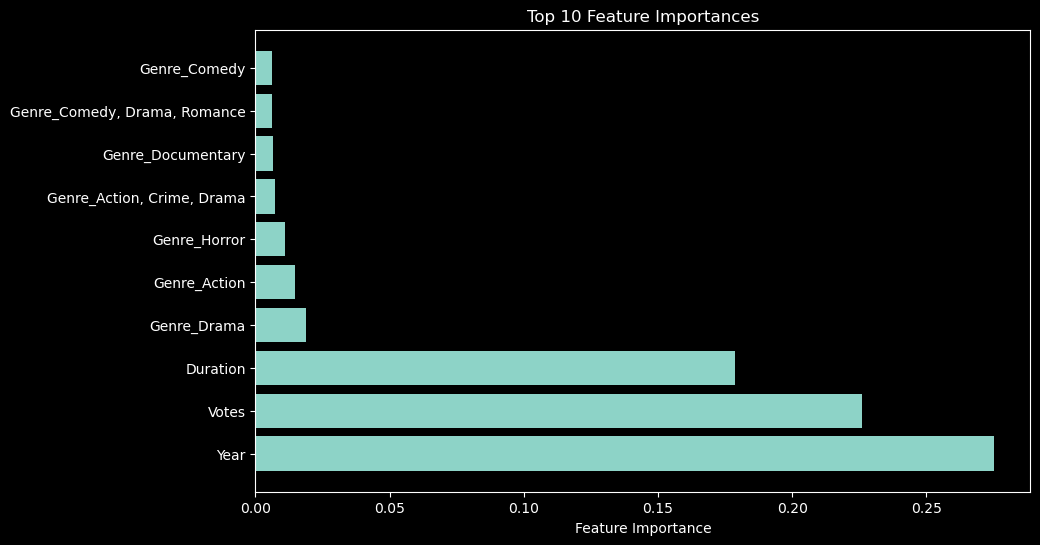

In [59]:
# Get feature importances from the best model
feature_importances = best_rf_model.feature_importances_

# Get the column names of your feature data 
feature_names = X_final.columns 
# Sort feature importances in descending order and get the top 10 features
top_indices = np.argsort(feature_importances)[::-1][:10]
top_features = [feature_names[i] for i in top_indices]
top_importances = [feature_importances[i] for i in top_indices]

# Create a bar plot to visualize feature importances
plt.figure(figsize=(10, 6))
plt.barh(range(10), top_importances, align='center')
plt.yticks(range(10), top_features)
plt.xlabel('Feature Importance')
plt.title('Top 10 Feature Importances')
plt.show()

Features that had most significant impact on the target variable in the above model:

Year,
Votes,
Duration

Conclusion
====================================
In conclusion, this project provides valuable insights and a predictive model for movie rating prediction. The film industry can benefit from these findings to make data-driven decisions regarding movie production, casting, and marketing. The most influential factors identified are the year of release, the number of votes, and movie duration.